# 02c: Explore structured site intervals — Volt-Watt / Volt-Var context

Read-only, DuckDB-backed exploration of `structured_site_intervals` (Delivery 2 output).
Nothing is written.

This notebook overlays the AS/NZS 4777.2:2020 Australia Region A Volt-Watt and
Volt-Var default set-points on a chosen site's voltage/power data, purely as a
**visual reference** for where the site sits relative to the standard's voltage
bands. It is **not** a conformance assessment:

- `formal_inverter_conformance_assessable = false` on every row here (see
  `METHODOLOGY_GATES.md`, gate 8). Household load and PV are not decomposed,
  the P/Q sign convention is a working hypothesis, phase-to-inverter mapping
  is inferred (not confirmed), and voltage is measured at the revenue meter,
  not the inverter terminals.
- Absolute-magnitude comparison against the standard requires a validated
  inverter rated apparent power (`S_rated`), which this dataset does not yet
  have (`s_rated_kva` is null — see `DATA_CONTRACT.md`). Any absolute-watt
  curve overlay below uses `solar_capacity_kw` only as an explicitly labelled,
  illustrative proxy — never silently as `S_rated`.
- Revenue-meter voltage typically *underestimates* inverter-terminal voltage
  during export (~1-3 V typical, up to 4-5 V on poor installations). A site
  that looks conformant here could still cross a breakpoint at the inverter.

The Volt-Watt/Volt-Var set-points themselves are copied from this project's
own validated source of truth for the Solar Analytics pipeline
(`bms_sa_review/shared/ciccada_config.py` and `as4777_curves.py`), reproduced
inline below in this project's `q_absorbing_var` sign convention. See the
markdown cell above the curve definitions for the sign-flip rationale.

In [13]:
from __future__ import annotations

import sys
from pathlib import Path
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

HERE = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in (HERE, *HERE.parents) if (p / 'src' / 'ausgrid_analysis').is_dir()), None)
assert PROJECT_ROOT is not None, 'Start Jupyter inside the ausgrid_analysis project.'
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
from ausgrid_analysis.config import load_config
from ausgrid_analysis.db import site_phase_profile_path, site_profile_path, structured_site_output_path
from ausgrid_analysis.metadata import metadata_output_path
from ausgrid_analysis.schemas import sql_string


pd.set_option('display.max_columns', 100)
plt.style.use('seaborn-v0_8-whitegrid')

## Select a bounded slice

Edit these values freely. `SERIAL=None` chooses a candidate site from the
selected month (a high phase-mapping-confidence site with the most
DER-phase-complete rows). `MAX_ROWS` is a hard guardrail.

The site-scoped query below filters on `site_bucket = mod(hash(serial), N)`
as well as `serial` itself — this lets DuckDB prune to a single hive
partition instead of scanning all ~140M rows / 5.7 GB.

In [14]:
CONFIG_PATH = PROJECT_ROOT / 'analysis.toml'
MONTH = '2025-04'
SERIAL = None
DATE_FROM = None  # local date, e.g. '2025-04-10'
DATE_TO = None    # local date, exclusive
MAX_ROWS = 100_000

config = load_config(CONFIG_PATH, check_inputs=False)
full_scope = config.scope(None, None)
bucket_count = config.processing.site_bucket_count

structured_site_dir = structured_site_output_path(config, full_scope)
assert structured_site_dir.is_dir(), f'Run notebook 02b first: {structured_site_dir}'
structured_site_glob = str(structured_site_dir / '**' / '*.parquet')

site_profile_file = site_profile_path(config, full_scope)
site_phase_profile_file = site_phase_profile_path(config, full_scope)
metadata_file = metadata_output_path(config)

con = duckdb.connect()
con.execute(f"SET memory_limit='{config.processing.memory_limit}'")
con.execute(f"SET threads={min(config.processing.threads, 4)}")
con.execute("SET TimeZone='UTC'")
con.execute(
    f"CREATE VIEW site_intervals AS "
    f"SELECT * FROM read_parquet({sql_string(structured_site_glob)}, hive_partitioning=true)"
)
con.execute(f"CREATE VIEW site_profile AS SELECT * FROM read_parquet({sql_string(site_profile_file)})")
con.execute(
    f"CREATE VIEW site_phase_profile AS SELECT * FROM read_parquet({sql_string(site_phase_profile_file)})"
)
con.execute(f"CREATE VIEW metadata AS SELECT * FROM read_parquet({sql_string(metadata_file)})")

print('structured_site_intervals source:', structured_site_dir)
print('site_profile source:', site_profile_file)
print('site_phase_profile source:', site_phase_profile_file)
print('metadata source:', metadata_file)

structured_site_intervals source: C:\Users\z3553082\OneDrive - UNSW\Documents\CICCADA - Data\Ausgrid\derived\structured_telemetry\structured_site_intervals
site_profile source: C:\Users\z3553082\OneDrive - UNSW\Documents\CICCADA - Data\Ausgrid\derived\structured_telemetry\site_profile.parquet
site_phase_profile source: C:\Users\z3553082\OneDrive - UNSW\Documents\CICCADA - Data\Ausgrid\derived\structured_telemetry\site_phase_profile.parquet
metadata source: C:\Users\z3553082\OneDrive - UNSW\Documents\CICCADA - Data\Ausgrid\derived\metadata\metadata_canonical.parquet


In [25]:
COHORT = 'solar_only'           # 'solar_only', 'solar_battery', or None for either
PHASE_COUNTS = (1, 3)           # install_phase_count values to allow; None for any
EXCLUDE_CONTROLLED_LOAD = True  # True -> keep only controlled_load == 'No'

year, month = map(int, MONTH.split('-'))
overview = con.execute('''
    SELECT count(*) n_rows, count(DISTINCT serial) n_sites,
           min(timestamp_local) first_local, max(timestamp_local) last_local,
           count_if(der_phase_power_complete) n_der_complete_rows,
           count_if(phase_mapping_confidence = 'high') n_high_confidence_rows,
           count_if(analysis_cohort = 'solar_battery') n_battery_rows
    FROM site_intervals WHERE year_utc=? AND month_utc=?
''', [year, month]).fetchdf()
display(overview)

where = ['si.year_utc = ?', 'si.month_utc = ?', "si.phase_mapping_confidence = 'high'"]
params = [year, month]
if COHORT is not None:
    where.append('si.analysis_cohort = ?')
    params.append(COHORT)
if PHASE_COUNTS is not None:
    where.append('sprof.install_phase_count IN (SELECT unnest(?))')
    params.append(list(PHASE_COUNTS))
if EXCLUDE_CONTROLLED_LOAD:
    where.append("lower(m.controlled_load) = 'no'")

site_choices_query = f'''
    SELECT si.serial, si.analysis_cohort, si.phase_mapping_confidence,
           sprof.install_phase_count, m.controlled_load,
           sp.solar_capacity_kw,
           count(*) n_rows,
           count_if(si.der_phase_power_complete) n_der_complete_rows
    FROM site_intervals si
    LEFT JOIN site_profile sprof USING (serial)
    LEFT JOIN metadata m USING (serial)
    LEFT JOIN (SELECT DISTINCT serial, solar_capacity_kw FROM site_phase_profile) sp USING (serial)
    WHERE {' AND '.join(where)}
    GROUP BY ALL
    ORDER BY n_der_complete_rows DESC, solar_capacity_kw DESC NULLS LAST
    LIMIT 30
'''
site_choices = con.execute(site_choices_query, params).fetchdf()
display(site_choices.head(20))
if SERIAL is None:
    SERIAL = str(site_choices.iloc[0]['serial'])
print('Selected serial:', SERIAL)

,n_rows,n_sites,first_local,last_local,n_der_complete_rows,n_high_confidence_rows,n_battery_rows
0,11384175,1336,2025-04-01 11:00:00,2025-05-01 09:55:00,5654807.0,5390432.0,3016772.0


,serial,analysis_cohort,phase_mapping_confidence,install_phase_count,controlled_load,solar_capacity_kw,n_rows,n_der_complete_rows
0,810584444,solar_only,high,3.0,No,16.799999,8640,8640.0
1,810886604,solar_only,high,3.0,No,16.600000,8640,8640.0
2,810635553,solar_only,high,3.0,No,14.940000,8640,8640.0
3,810409509,solar_only,high,3.0,No,13.200000,8640,8640.0
4,811026604,solar_only,high,1.0,No,13.200000,8640,8640.0
5,810886914,solar_only,high,3.0,No,13.175000,8640,8640.0
6,810196286,solar_only,high,3.0,No,13.120000,8640,8640.0
7,810870441,solar_only,high,3.0,No,12.750000,8640,8640.0
8,810976771,solar_only,high,3.0,No,10.375000,8640,8640.0
9,810960457,solar_only,high,3.0,No,10.125000,8640,8640.0


Selected serial: 810584444


In [18]:
# Change SERIAL if wanted, e.g.:
# SERIAL = 810976771

In [34]:
where = ['year_utc=?', 'month_utc=?', 'serial=?', f'site_bucket = mod(hash(?), {bucket_count})']
params = [year, month, str(SERIAL), str(SERIAL)]
if DATE_FROM:
    where.append('timestamp_local >= cast(? as timestamp)'); params.append(DATE_FROM)
if DATE_TO:
    where.append('timestamp_local < cast(? as timestamp)'); params.append(DATE_TO)
query = f'''SELECT * FROM site_intervals WHERE {" AND ".join(where)} ORDER BY timestamp_utc LIMIT ?'''
sample = con.execute(query, [*params, MAX_ROWS]).fetchdf()

sample['q_generator_der_phase_net_complete_var'] = -sample['q_absorbing_der_phase_net_complete_var']
sample['q_generator_net_observed_var'] = -sample['q_absorbing_net_observed_var']

assert len(sample) < MAX_ROWS, 'Row cap reached: narrow the date range before interpreting plots.'
assert len(sample) > 0, 'No rows for this serial/month/date combination.'
display(sample.head())
display(sample[[
    'voltage_mean_valid_v', 'der_voltage_mean_valid_v',
    'p_export_net_observed_w', 'p_export_der_phase_net_complete_w',
    'q_absorbing_net_observed_var', 'q_absorbing_der_phase_net_complete_var',
]].describe())
print('DER-phase-complete rows:', int(sample['der_phase_power_complete'].sum()), '/', len(sample))

,serial,timestamp_utc,timestamp_local,local_date,local_hour,local_minute,utc_offset_minutes,metadata_available,analysis_cohort,has_battery,phase_mapping_method,phase_mapping_confidence,phase_mapping_assessable,solar_only_mapped_cohort,observed_phase_rows,measured_power_phase_rows,expected_der_phase_rows,measured_der_phase_rows,voltage_min_valid_v,voltage_mean_valid_v,voltage_max_valid_v,der_voltage_min_valid_v,der_voltage_mean_valid_v,der_voltage_max_valid_v,p_export_net_observed_w,q_absorbing_net_observed_var,p_export_der_phase_net_observed_w,q_absorbing_der_phase_net_observed_var,voltage_a_v,voltage_b_v,voltage_c_v,p_export_a_w,p_export_b_w,p_export_c_w,der_phase_power_complete,p_export_der_phase_net_complete_w,q_absorbing_der_phase_net_complete_var,measurement_basis,voltage_measurement_location,formal_inverter_conformance_assessable,month_utc,site_bucket,year_utc,q_generator_der_phase_net_complete_var,q_generator_net_observed_var
0,810584444,2025-04-01 00:00:00+00:00,2025-04-01 11:00:00,2025-04-01,11,0,660,True,solar_only,False,all_power_available_phases,high,True,True,3,3.0,3.0,3.0,238.474228,244.627274,248.739609,238.474228,244.627274,248.739609,949.566832,-1107.827969,949.566832,-1107.827969,246.667984,238.474228,248.739609,1735.76733,-781.095300,-5.105198,True,949.566832,-1107.827969,net_meter,revenue_meter,False,4,27,2025,1107.827969,1107.827969
1,810584444,2025-04-01 00:05:00+00:00,2025-04-01 11:05:00,2025-04-01,11,5,660,True,solar_only,False,all_power_available_phases,high,True,True,3,3.0,3.0,3.0,237.979500,243.359555,246.997787,237.979500,243.359555,246.997787,163.366242,-1342.667083,163.366242,-1342.667083,245.101379,237.979500,246.997787,1858.29200,-1689.820560,-5.105198,True,163.366242,-1342.667083,net_meter,revenue_meter,False,4,27,2025,1342.667083,1342.667083
2,810584444,2025-04-01 00:10:00+00:00,2025-04-01 11:10:00,2025-04-01,11,10,660,True,solar_only,False,all_power_available_phases,high,True,True,3,3.0,3.0,3.0,238.783432,243.486679,246.028976,238.783432,243.486679,246.028976,1659.189358,-1414.139790,1659.189358,-1414.139790,245.647629,238.783432,246.028976,2578.12500,-913.830444,-5.105198,True,1659.189358,-1414.139790,net_meter,revenue_meter,False,4,27,2025,1414.139790,1414.139790
3,810584444,2025-04-01 00:15:00+00:00,2025-04-01 11:15:00,2025-04-01,11,15,660,True,solar_only,False,all_power_available_phases,high,True,True,3,3.0,3.0,3.0,239.855316,244.589483,248.203659,239.855316,244.589483,248.203659,3864.634742,-2562.809303,3864.634742,-2562.809303,248.203659,239.855316,245.709473,3446.00854,423.731400,-5.105198,True,3864.634742,-2562.809303,net_meter,revenue_meter,False,4,27,2025,2562.809303,2562.809303
4,810584444,2025-04-01 00:20:00+00:00,2025-04-01 11:20:00,2025-04-01,11,20,660,True,solar_only,False,all_power_available_phases,high,True,True,3,3.0,3.0,3.0,239.669800,244.840281,248.801453,239.669800,244.840281,248.801453,2225.866392,-2470.915594,2225.866392,-2470.915594,248.801453,239.669800,246.049591,2353.49634,-122.524750,-5.105198,True,2225.866392,-2470.915594,net_meter,revenue_meter,False,4,27,2025,2470.915594,2470.915594


,voltage_mean_valid_v,der_voltage_mean_valid_v,p_export_net_observed_w,p_export_der_phase_net_complete_w,q_absorbing_net_observed_var,q_absorbing_der_phase_net_complete_var
count,8640.000000,8640.000000,8640.000000,8640.000000,8640.000000,8640.000000
mean,243.757827,243.757827,-277.497642,-277.497642,-411.705256,-411.705256
std,1.403548,1.403548,2287.677691,2287.677691,1270.232628,1270.232628
min,237.842092,237.842092,-12308.631740,-12308.631740,-5008.199275,-5008.199275
25%,242.878589,242.878589,-985.303203,-985.303203,-1194.616290,-1194.616290
50%,243.775259,243.775259,-525.835392,-525.835392,275.680690,275.680690
75%,244.703714,244.703714,311.417138,311.417138,581.992584,581.992584
max,247.757045,247.757045,8719.678012,8719.678012,786.200474,786.200474


DER-phase-complete rows: 8640 / 8640


## AS/NZS 4777.2:2020 Australia Region A Volt-Watt / Volt-Var reference curves

Set-points below are copied from `bms_sa_review/shared/ciccada_config.py`
(`AS4777` dict) and `as4777_curves.py` (`vw_max_p`, `vvar_required_q`) —
this project's already-validated source of truth for the Solar Analytics
Volt-Var/Volt-Watt pipeline. They are **not** independently re-derived from
the standard here; if in doubt, re-check against the standard directly.

**Sign convention.** The Solar Analytics module uses the *generator*
convention (`+Q` = supplying, `-Q` = absorbing). `ausgrid_analysis` uses the
*absorbing* convention (`q_absorbing_var`: `+Q` = absorbing), and
`q_absorbing_var = -q_generator_var` (see `schemas.py`). Every fraction below
is therefore the negative of the corresponding `as4777_curves.py`
generator-convention output: supplying at V1 becomes `Q1 = -0.44`, absorbing
at V4 becomes `Q4 = +0.60`. Cross-check against
`config.assumptions.reactive_absorbing_sign` before trusting the sign of any
plotted value.

In [35]:
# Copied verbatim from bms_sa_review/shared/ciccada_config.py (AS4777 dict), Australia Region A.
# Generator convention (AS/NZS 4777.2 Fig 3.2, same convention as4777_curves.py uses):
#   +Q = supplying/injecting, -Q = absorbing/consuming. No sign flip here.
AS4777_VW = {'V1': 253.0, 'V2': 260.0, 'P1': 1.00, 'P2': 0.20}
AS4777_VVAR = {'V1': 207.0, 'V2': 220.0, 'V3': 240.0, 'V4': 258.0, 'Q1': 0.44, 'Q4': -0.60}
AS4777_TOL_FRAC = 0.04  # +/- 4% of the capacity reference, additive (as4777_curves.add_tol_kw)


def vw_max_p_fraction(voltage_v, v1=AS4777_VW['V1'], v2=AS4777_VW['V2'],
                       p1=AS4777_VW['P1'], p2=AS4777_VW['P2']):
    """Volt-Watt max-P limit as a fraction of the capacity reference."""
    v = np.asarray(voltage_v, dtype=float)
    return np.interp(v, [v1, v2], [p1, p2])


def vvar_required_q_fraction(voltage_v, v1=AS4777_VVAR['V1'], v2=AS4777_VVAR['V2'],
                              v3=AS4777_VVAR['V3'], v4=AS4777_VVAR['V4'],
                              q1=AS4777_VVAR['Q1'], q4=AS4777_VVAR['Q4']):
    """Volt-Var required-Q set-point as a fraction of the capacity reference (generator convention)."""
    v = np.asarray(voltage_v, dtype=float)
    return np.interp(v, [v1, v2, v3, v4], [q1, 0.0, 0.0, q4])


voltage_grid = np.linspace(200, 265, 260)
vw_curve = vw_max_p_fraction(voltage_grid)
vvar_curve = vvar_required_q_fraction(voltage_grid)
print('Volt-Watt breakpoints (V):', AS4777_VW)
print('Volt-Var breakpoints (V, generator convention — matches AS/NZS4777.2 Fig 3.2 directly):', AS4777_VVAR)

Volt-Watt breakpoints (V): {'V1': 253.0, 'V2': 260.0, 'P1': 1.0, 'P2': 0.2}
Volt-Var breakpoints (V, generator convention — matches AS/NZS4777.2 Fig 3.2 directly): {'V1': 207.0, 'V2': 220.0, 'V3': 240.0, 'V4': 258.0, 'Q1': 0.44, 'Q4': -0.6}


Using voltage=der_voltage_mean_valid_v, P=p_export_der_phase_net_complete_w, Q=q_generator_der_phase_net_complete_var


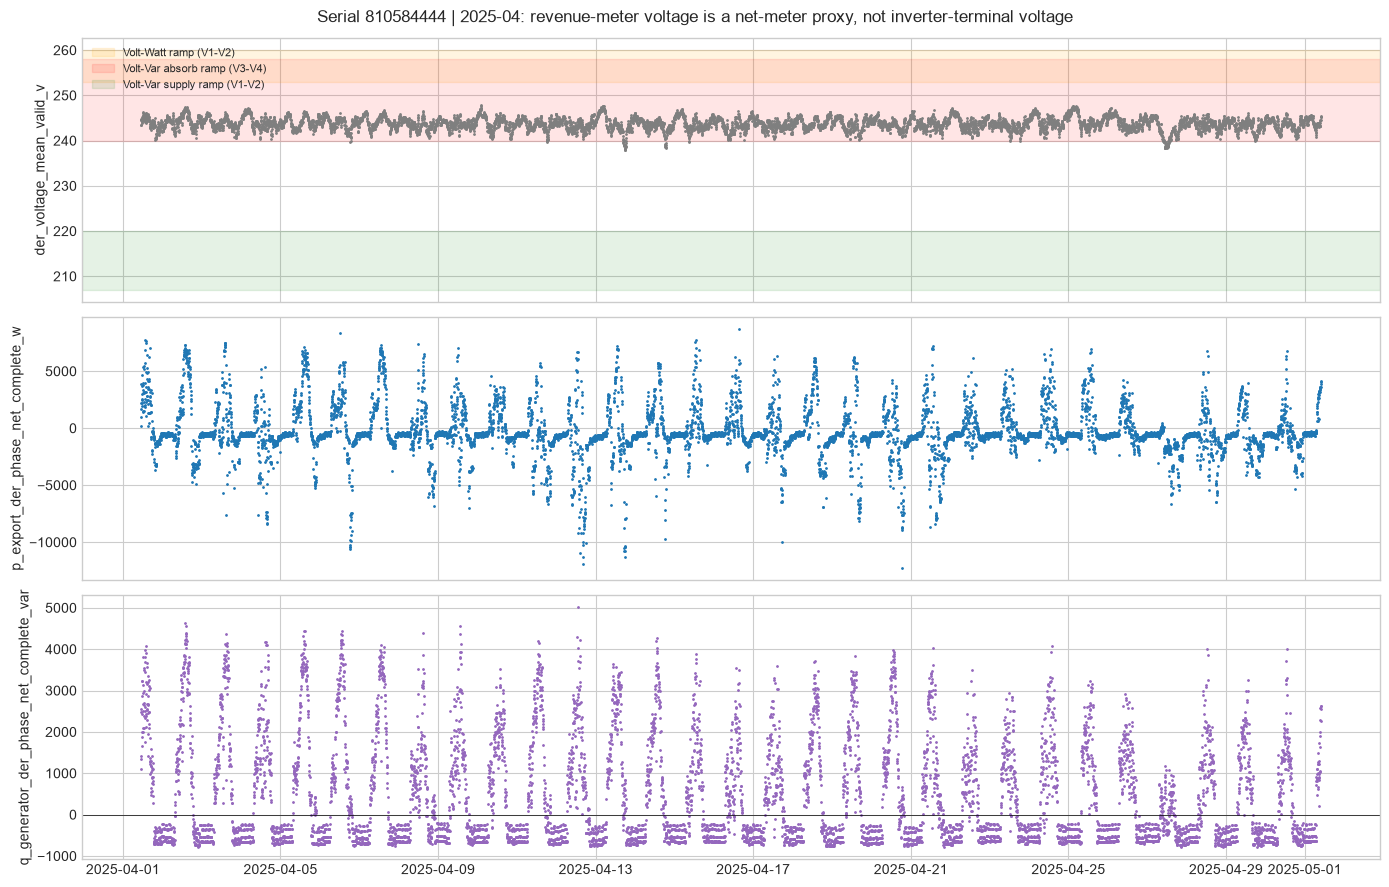

In [36]:
voltage_col = 'der_voltage_mean_valid_v' if sample['der_voltage_mean_valid_v'].notna().any() else 'voltage_mean_valid_v'
p_col = 'p_export_der_phase_net_complete_w' if sample['p_export_der_phase_net_complete_w'].notna().any() else 'p_export_net_observed_w'
q_col = 'q_generator_der_phase_net_complete_var' if sample['q_generator_der_phase_net_complete_var'].notna().any() else 'q_generator_net_observed_var'

print(f'Using voltage={voltage_col}, P={p_col}, Q={q_col}')
if p_col == 'p_export_net_observed_w':
    print('Note: DER-phase-complete P/Q were all null for this slice; falling back to whole-site net values, '
          'which include any non-DER (load-only) phases.')

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
axes[0].plot(sample.timestamp_local, sample[voltage_col], '.', ms=2, color='tab:gray')
axes[0].axhspan(AS4777_VW['V1'], AS4777_VW['V2'], color='orange', alpha=.12, label='Volt-Watt ramp (V1-V2)')
axes[0].axhspan(AS4777_VVAR_ABSORBING['V3'], AS4777_VVAR_ABSORBING['V4'], color='red', alpha=.10, label='Volt-Var absorb ramp (V3-V4)')
axes[0].axhspan(AS4777_VVAR_ABSORBING['V1'], AS4777_VVAR_ABSORBING['V2'], color='green', alpha=.10, label='Volt-Var supply ramp (V1-V2)')
axes[0].set_ylabel(voltage_col); axes[0].legend(fontsize=8, ncol=1, loc='upper left')

axes[1].plot(sample.timestamp_local, sample[p_col], '.', ms=2, color='tab:blue')
axes[1].set_ylabel(p_col)

axes[2].plot(sample.timestamp_local, sample[q_col], '.', ms=2, color='tab:purple')
axes[2].axhline(0, color='k', lw=.5)
axes[2].set_ylabel(q_col)

fig.suptitle(f'Serial {SERIAL} | {MONTH}: revenue-meter voltage is a net-meter proxy, not inverter-terminal voltage')
plt.tight_layout()
plt.show()

,solar_capacity_kw,approved_capacity_kw,battery_inverter_capacity_kw
0,16.799999,20,0.0


Illustrative capacity proxy: solar_capacity_kw=16.799999237060547 kW. This is NOT a validated S_rated (DATA_CONTRACT.md) -- treat the absolute-W/VAr overlay below as a rough sense-check only.


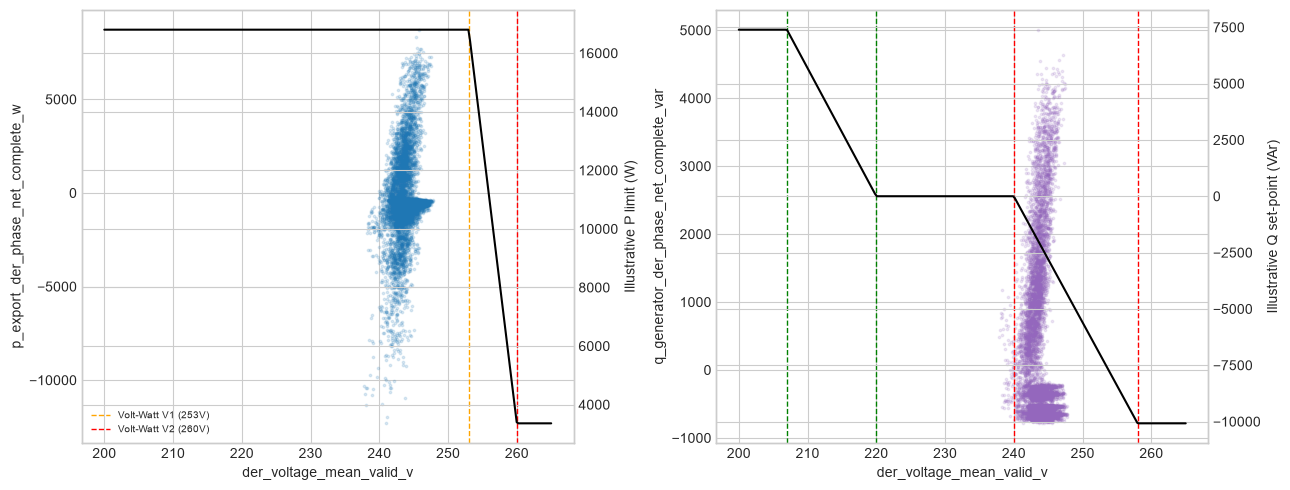

In [37]:
valid = sample[sample[voltage_col].notna() & sample[p_col].notna() & sample[q_col].notna()]

capacity_row = con.execute(
    'SELECT DISTINCT solar_capacity_kw, approved_capacity_kw, battery_inverter_capacity_kw '
    'FROM site_phase_profile WHERE serial = ?',
    [str(SERIAL)],
).fetchdf()
display(capacity_row)
capacity_kw = None
if len(capacity_row) and pd.notna(capacity_row['solar_capacity_kw'].iloc[0]):
    capacity_kw = float(capacity_row['solar_capacity_kw'].iloc[0])
    print(f'Illustrative capacity proxy: solar_capacity_kw={capacity_kw} kW. '
          'This is NOT a validated S_rated (DATA_CONTRACT.md) -- treat the absolute-W/VAr '
          'overlay below as a rough sense-check only.')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(valid[voltage_col], valid[p_col], s=3, alpha=.15, color='tab:blue')
axes[0].axvline(AS4777_VW['V1'], color='orange', ls='--', lw=1, label='Volt-Watt V1 (253V)')
axes[0].axvline(AS4777_VW['V2'], color='red', ls='--', lw=1, label='Volt-Watt V2 (260V)')
if capacity_kw:
    ax0b = axes[0].twinx()
    ax0b.plot(voltage_grid, vw_curve * capacity_kw * 1000, color='k', lw=1.5,
              label='AS4777 P limit (illustrative, capacity-scaled)')
    ax0b.set_ylabel('Illustrative P limit (W)')
axes[0].set(xlabel=voltage_col, ylabel=p_col); axes[0].legend(fontsize=7, loc='lower left')

axes[1].scatter(valid[voltage_col], valid[q_col], s=3, alpha=.15, color='tab:purple')
for key, color in [('V1', 'green'), ('V2', 'green'), ('V3', 'red'), ('V4', 'red')]:
    axes[1].axvline(AS4777_VVAR_ABSORBING[key], color=color, ls='--', lw=1)
if capacity_kw:
    ax1b = axes[1].twinx()
    ax1b.plot(voltage_grid, vvar_curve * capacity_kw * 1000, color='k', lw=1.5,
              label='AS4777 Q set-point (illustrative, capacity-scaled)')
    ax1b.set_ylabel('Illustrative Q set-point (VAr)')
axes[1].set(xlabel=voltage_col, ylabel=q_col)
plt.tight_layout()
plt.show()

## Provenance / data-quality context for this site

In [38]:
profile = con.execute('SELECT * FROM site_profile WHERE serial = ?', [str(SERIAL)]).fetchdf()
display(profile)

phase_detail = con.execute(
    'SELECT phase, n_rows, power_measurement_available, solar_signature_w, '
    'solar_capacity_kw, approved_capacity_kw, battery_inverter_capacity_kw '
    'FROM site_phase_profile WHERE serial = ?',
    [str(SERIAL)],
).fetchdf()
display(phase_detail)

n_assessable = int(sample['formal_inverter_conformance_assessable'].sum())
assert n_assessable == 0, 'Expected formal_inverter_conformance_assessable=False on every Delivery 2 row (METHODOLOGY_GATES.md).'
print(f'formal_inverter_conformance_assessable=False on all {len(sample)} rows, as required at this delivery stage.')
print('measurement_basis:', sample['measurement_basis'].unique())
print('voltage_measurement_location:', sample['voltage_measurement_location'].unique())
print('Working signs — active export:', config.assumptions.active_export_sign,
      '; reactive absorbing:', config.assumptions.reactive_absorbing_sign)
print('Close connection when finished: con.close()')

,serial,metadata_available,analysis_cohort,has_battery,install_phase_count,observed_phase_count,observed_phases,power_phase_count,power_available_phases,inferred_der_phases,phase_mapping_method,phase_mapping_confidence,phase_mapping_sign_dependency,phase_mapping_requires_review,phase_mapping_margin_ratio,top_solar_signature_w,phase_mapping_assessable,solar_only_mapped_cohort,measurement_basis,voltage_measurement_location,formal_inverter_conformance_assessable
0,810584444,True,solar_only,False,3.0,3,A|B|C,3,A|B|C,A|B|C,all_power_available_phases,high,not_sign_ranked,True,NaN,NaN,True,True,net_meter,revenue_meter,False


,phase,n_rows,power_measurement_available,solar_signature_w,solar_capacity_kw,approved_capacity_kw,battery_inverter_capacity_kw
0,A,105120,True,2564.013025,16.799999,20,0.0
1,B,105120,True,-598.653141,16.799999,20,0.0
2,C,105120,True,0.000000,16.799999,20,0.0


formal_inverter_conformance_assessable=False on all 8640 rows, as required at this delivery stage.
measurement_basis: <ArrowStringArray>
['net_meter']
Length: 1, dtype: str
voltage_measurement_location: <ArrowStringArray>
['revenue_meter']
Length: 1, dtype: str
Working signs — active export: -1 ; reactive absorbing: -1
Close connection when finished: con.close()


## Look at another site

Change `SERIAL` (and optionally `MONTH`/`DATE_FROM`/`DATE_TO`) in the cell
above the site shortlist, then re-run from that cell down through the plots.

In [39]:
sample

,serial,timestamp_utc,timestamp_local,local_date,local_hour,local_minute,utc_offset_minutes,metadata_available,analysis_cohort,has_battery,phase_mapping_method,phase_mapping_confidence,phase_mapping_assessable,solar_only_mapped_cohort,observed_phase_rows,measured_power_phase_rows,expected_der_phase_rows,measured_der_phase_rows,voltage_min_valid_v,voltage_mean_valid_v,voltage_max_valid_v,der_voltage_min_valid_v,der_voltage_mean_valid_v,der_voltage_max_valid_v,p_export_net_observed_w,q_absorbing_net_observed_var,p_export_der_phase_net_observed_w,q_absorbing_der_phase_net_observed_var,voltage_a_v,voltage_b_v,voltage_c_v,p_export_a_w,p_export_b_w,p_export_c_w,der_phase_power_complete,p_export_der_phase_net_complete_w,q_absorbing_der_phase_net_complete_var,measurement_basis,voltage_measurement_location,formal_inverter_conformance_assessable,month_utc,site_bucket,year_utc,q_generator_der_phase_net_complete_var,q_generator_net_observed_var
0,810584444,2025-04-01 00:00:00+00:00,2025-04-01 11:00:00,2025-04-01,11,0,660,True,solar_only,False,all_power_available_phases,high,True,True,3,3.0,3.0,3.0,238.474228,244.627274,248.739609,238.474228,244.627274,248.739609,949.566832,-1107.827969,949.566832,-1107.827969,246.667984,238.474228,248.739609,1735.767330,-781.095300,-5.105198,True,949.566832,-1107.827969,net_meter,revenue_meter,False,4,27,2025,1107.827969,1107.827969
1,810584444,2025-04-01 00:05:00+00:00,2025-04-01 11:05:00,2025-04-01,11,5,660,True,solar_only,False,all_power_available_phases,high,True,True,3,3.0,3.0,3.0,237.979500,243.359555,246.997787,237.979500,243.359555,246.997787,163.366242,-1342.667083,163.366242,-1342.667083,245.101379,237.979500,246.997787,1858.292000,-1689.820560,-5.105198,True,163.366242,-1342.667083,net_meter,revenue_meter,False,4,27,2025,1342.667083,1342.667083
2,810584444,2025-04-01 00:10:00+00:00,2025-04-01 11:10:00,2025-04-01,11,10,660,True,solar_only,False,all_power_available_phases,high,True,True,3,3.0,3.0,3.0,238.783432,243.486679,246.028976,238.783432,243.486679,246.028976,1659.189358,-1414.139790,1659.189358,-1414.139790,245.647629,238.783432,246.028976,2578.125000,-913.830444,-5.105198,True,1659.189358,-1414.139790,net_meter,revenue_meter,False,4,27,2025,1414.139790,1414.139790
3,810584444,2025-04-01 00:15:00+00:00,2025-04-01 11:15:00,2025-04-01,11,15,660,True,solar_only,False,all_power_available_phases,high,True,True,3,3.0,3.0,3.0,239.855316,244.589483,248.203659,239.855316,244.589483,248.203659,3864.634742,-2562.809303,3864.634742,-2562.809303,248.203659,239.855316,245.709473,3446.008540,423.731400,-5.105198,True,3864.634742,-2562.809303,net_meter,revenue_meter,False,4,27,2025,2562.809303,2562.809303
4,810584444,2025-04-01 00:20:00+00:00,2025-04-01 11:20:00,2025-04-01,11,20,660,True,solar_only,False,all_power_available_phases,high,True,True,3,3.0,3.0,3.0,239.669800,244.840281,248.801453,239.669800,244.840281,248.801453,2225.866392,-2470.915594,2225.866392,-2470.915594,248.801453,239.669800,246.049591,2353.496340,-122.524750,-5.105198,True,2225.866392,-2470.915594,net_meter,revenue_meter,False,4,27,2025,2470.915594,2470.915594
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8635,810584444,2025-04-30 23:35:00+00:00,2025-05-01 09:35:00,2025-05-01,9,35,600,True,solar_only,False,all_power_available_phases,high,True,True,3,3.0,3.0,3.0,242.854538,244.424581,246.935959,242.854538,244.424581,246.935959,3573.638524,-2567.914606,3573.638524,-2567.914606,246.935959,243.483246,242.854538,311.417084,3262.221440,0.000000,True,3573.638524,-2567.914606,net_meter,revenue_meter,False,4,27,2025,2567.914606,2567.914606
8636,810584444,2025-04-30 23:40:00+00:00,2025-05-01 09:40:00,2025-05-01,9,40,600,True,solar_only,False,all_power_available_phases,high,True,True,3,3.0,3.0,3.0,242.504120,244.616969,246.832886,242.504120,244.616969,246.832886,4012.685602,-2261.602688,4012.685602,-2261.60268